Images : 118
Neurons: 39209

Animacy score: -1.0328

=== PC-DECOY ADVERSARIAL TEST ===
Decoy mean : -1.0778592103689184
Decoy max  : -0.8440636560637426
Empirical p: 0.3333333333333333


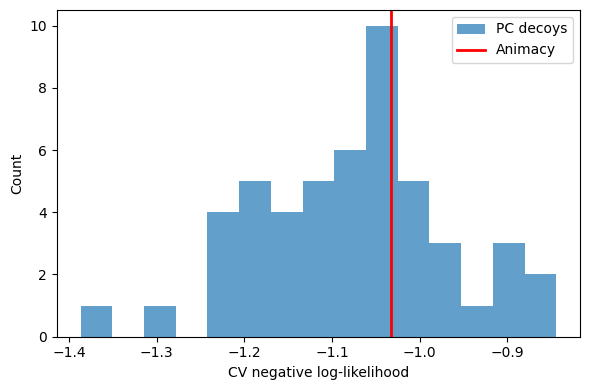

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================
vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("Images :", vit.shape[0])
print("Neurons:", R.shape[1])

# ============================================================
# ANIMATE / INANIMATE LABEL
# ============================================================
top1 = np.argmax(vit, axis=1)
y_anim = (top1 <= 397).astype(int)   # ImageNet animate split

# ============================================================
# PCA ON ViT LOGITS (STIMULUS SPACE)
# ============================================================
vit_z = StandardScaler().fit_transform(vit)
scores = PCA().fit_transform(vit_z)   # (images, 1000)

# ============================================================
# NEURAL PREPROCESSING
# ============================================================
X = StandardScaler().fit_transform(R)

# ============================================================
# LOGISTIC SCORE (CV NEG LOG-LIKELIHOOD)
# ============================================================
def logistic_score(X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    vals = []

    for tr, te in cv.split(X, y):
        clf = LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=500
        )
        clf.fit(X[tr], y[tr])
        p = clf.predict_proba(X[te])[:, 1]
        vals.append(-log_loss(y[te], p))

    return np.mean(vals)

# ============================================================
# REAL ANIMACY SCORE
# ============================================================
T_anim = logistic_score(X, y_anim)
print(f"\nAnimacy score: {T_anim:.4f}")

# ============================================================
# PC DECOY POPULATION (MEDIAN SPLITS)
# ============================================================
K = 50          # PCs 2..51
T_decoy = []

for k in range(1, K + 1):
    pc = scores[:, k]
    y_k = (pc > np.median(pc)).astype(int)
    T_decoy.append(logistic_score(X, y_k))

T_decoy = np.array(T_decoy)

# ============================================================
# ADVERSARIAL COMPARISON
# ============================================================
p_empirical = (1 + np.sum(T_decoy >= T_anim)) / (1 + len(T_decoy))

print("\n=== PC-DECOY ADVERSARIAL TEST ===")
print("Decoy mean :", T_decoy.mean())
print("Decoy max  :", T_decoy.max())
print("Empirical p:", p_empirical)

# ============================================================
# VISUALIZATION
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(T_decoy, bins=15, alpha=0.7, label='PC decoys')
plt.axvline(T_anim, color='red', lw=2, label='Animacy')
plt.xlabel("CV negative log-likelihood")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
